# How does the C-rate affect DVA

In [1]:
import os
import sys
import math
sys.path.append(os.path.join(os.getcwd().partition('EV_DVA_Robustness')[0], "EV_DVA_Robustness"))
from src.config_base import GeneralConfig

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator, FixedLocator
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

In [3]:
from src.data.read_feather import ReadFeather
from src.filtering.filter_methods import FilterMethods
from src.voltage_capacity_analysis.ica import ICA
from src.voltage_capacity_analysis.dva import DVA
from src.visualization.config_visualization import VisualizationConfig, instantiate_matplotlib_parameters, cm2inch
instantiate_matplotlib_parameters()
from src.visualization.colormaps import ColorMaps

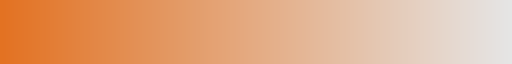

In [4]:
tum_orange_cmap = ColorMaps.orange_tum()
orange_colors = tum_orange_cmap(np.linspace(0,1, 5))
tum_orange_cmap

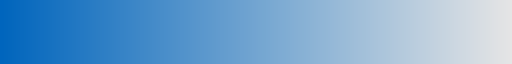

In [5]:
tum_blue_cmap = ColorMaps.blue_tum()
blue_colors = tum_blue_cmap(np.linspace(0,1, 5))
tum_blue_cmap

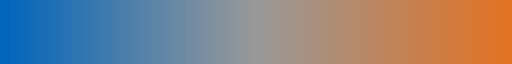

In [6]:
tum_cmap = ColorMaps.blue_orange_tum(grayscale=0.6)
colors = tum_cmap(np.linspace(0,1, 5))
colors = colors[[0,1,3,4]]
tum_cmap

In [7]:
def filter_func_preprocess_U(signal):
    perc_filter = 1/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal.values[:,0]

In [8]:
def filter_func_preprocess_Q(signal):
    perc_filter = 1/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal

In [9]:
def filter_func_preprocess_I(signal):
    perc_filter = 0.5/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal

In [10]:
read_feather = ReadFeather()
#read_feather.set_filter_U(filter_func_preprocess_U)
read_feather.set_filter_Q(filter_func_preprocess_Q)

## C-Rate Data

In [11]:
%%capture
df_vw_288_C45 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) # filtering at the left border reduces the steep flank
df_vw_288_C17 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_6A_CEE16_C17.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_288_C10 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_10A_CEE16_C10.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_288_C6 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_32A_CEE32_C6.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 

In [12]:
%%capture
df_tesla_C57 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_JB_6A_CEE7_C57_2022_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 
df_tesla_C17 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_AC_5A_C17_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 
df_tesla_C10 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_AC_8A_C10_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 
#df_tesla_C8= read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_AC_10A_C8_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 
df_tesla_C5= read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_AC_16A_C5_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380)

In [13]:
def filter_func_v(signal):
    perc_filter = 1 #% filter
    filtered_signal = FilterMethods().rolling_mean_numpy(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    filtered_signal_reverse = FilterMethods().rolling_mean_numpy(np.flip(signal),window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return (filtered_signal+np.flip(filtered_signal_reverse))/2

In [14]:
dva_extractor = DVA()
dva_extractor.set_filter(filter_func_v)

In [15]:
dva_vw_288_C45, cap_vw_288_C45 =dva_extractor.get_dva(time=df_vw_288_C45["time_h"], capacity=df_vw_288_C45["Q"], voltage=filter_func_preprocess_U(df_vw_288_C45["U"]),crop_cap_Ah=(7,180)) # due to the filtering the left side shows a weird behavior. the calculation of the electrode capacities is not affected
dva_vw_288_C17, cap_vw_288_C17 =dva_extractor.get_dva(time=df_vw_288_C17["time_h"], capacity=df_vw_288_C17["Q"], voltage=filter_func_preprocess_U(df_vw_288_C17["U"]),crop_cap_Ah=(1,180))
dva_vw_288_C10, cap_vw_288_C10 =dva_extractor.get_dva(time=df_vw_288_C10["time_h"], capacity=df_vw_288_C10["Q"], voltage=filter_func_preprocess_U(df_vw_288_C10["U"]),crop_cap_Ah=(1,180))
dva_vw_288_C6,  cap_vw_288_C6 =dva_extractor.get_dva(time=df_vw_288_C6["time_h"], capacity=df_vw_288_C6["Q"], voltage=filter_func_preprocess_U(df_vw_288_C6["U"]),crop_cap_Ah=(0,180))

In [16]:
Q_stage2_vw_C45 = dva_extractor.get_graphite_peak_location(cap_vw_288_C45,dva_vw_288_C45,75,90,n_parallel=1)
Q_stage2_vw_C6 = dva_extractor.get_graphite_peak_location(cap_vw_288_C6,dva_vw_288_C6,75,90,n_parallel=1)

In [17]:
# calc R diff  
idx_C45 = df_vw_288_C45.iloc[(df_vw_288_C45.Q-Q_stage2_vw_C45).abs().argsort()[:2]].index[0]
idx_C6 = df_vw_288_C6.iloc[(df_vw_288_C6.Q-Q_stage2_vw_C6).abs().argsort()[:2]].index[0]

dU  = df_vw_288_C6.loc[idx_C6,"U"]-df_vw_288_C45.loc[idx_C45,"U"]
window = 15
dI  = np.mean(df_vw_288_C6.loc[idx_C6-window:idx_C6+window,"I"])-np.mean(df_vw_288_C45.loc[idx_C45-window:idx_C45+window,"I"])

dR = dU/dI*1000
print(round(dR))
print(round(dI))

126
22


In [18]:
dva_tesla_C57, cap_tesla_C57 =dva_extractor.get_dva(time=df_tesla_C57["time_h"], capacity=df_tesla_C57["Q"], voltage=filter_func_preprocess_U(df_tesla_C57["U"]),crop_cap_Ah=(1,180))
dva_tesla_C17, cap_tesla_C17 =dva_extractor.get_dva(time=df_tesla_C17["time_h"], capacity=df_tesla_C17["Q"], voltage=filter_func_preprocess_U(df_tesla_C17["U"]),crop_cap_Ah=(0,180))
dva_tesla_C10, cap_tesla_C10 =dva_extractor.get_dva(time=df_tesla_C10["time_h"], capacity=df_tesla_C10["Q"], voltage=filter_func_preprocess_U(df_tesla_C10["U"]),crop_cap_Ah=(0,180))
#dva_tesla_C8, cap_tesla_C8 =dva_extractor.get_dva(time=df_tesla_C8["time_h"], capacity=df_tesla_C8["Q"], voltage=filter_func_preprocess_U(df_tesla_C8["U"]),crop_cap_Ah=(0,180))
dva_tesla_C5,  cap_tesla_C5 =dva_extractor.get_dva(time=df_tesla_C5["time_h"], capacity=df_tesla_C5["Q"], voltage=filter_func_preprocess_U(df_tesla_C5["U"]),crop_cap_Ah=(0,180))

In [19]:
Q_stage2_tesla_C57 = dva_extractor.get_graphite_peak_location(cap_tesla_C57,dva_tesla_C57,75,100,n_parallel=1)
Q_stage2_tesla_C5 = dva_extractor.get_graphite_peak_location(cap_tesla_C5,dva_tesla_C5,75,100,n_parallel=1)

In [20]:
# calc R diff  
idx_C57 = df_tesla_C57.iloc[(df_tesla_C57.Q-Q_stage2_tesla_C57).abs().argsort()[:2]].index[0]
idx_C5 = df_tesla_C5.iloc[(df_tesla_C5.Q-Q_stage2_tesla_C5).abs().argsort()[:2]].index[0]

dU  = df_tesla_C5.loc[idx_C5,"U"]-df_tesla_C57.loc[idx_C57,"U"]
window = 15
dI  = np.mean(df_tesla_C5.loc[idx_C5-window:idx_C5+window,"I"])-np.mean(df_tesla_C57.loc[idx_C57-window:idx_C57+window,"I"])

dR = dU/dI*1000
print(round(dR))
print(round(dI))

57
27


## Plot

In [21]:
def plot_current_vw(axes, lst_dfs = []):
    
    for ind,data in enumerate(lst_dfs):
        axes.plot(lst_dfs[ind].time_h,filter_func_preprocess_I(lst_dfs[ind].I),color=colors[ind],linewidth=1.5)
    
    axes.set_ylabel(r"Current in A",fontsize=9)
    axes.set_xlabel(r"Charging time in h",fontsize=9)
    axes.set_xlim([0,42])
    tick_positions = np.array([0,8,16,24,32,42])
    axes.set_xticks(tick_positions)
    axes.set_ylim([0,32])
    tick_positions = np.array([0,8,16,24,32])
    axes.set_yticks(tick_positions)
    axes.xaxis.set_minor_locator(FixedLocator([4,12,20,28,36,40]))
    axes.grid(axis='both')
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    axes.yaxis.set_label_coords(-0.13,0.5)
    
    # axes.annotate(text='$T=\,41\,h$',xy=(141,25),xytext=(141,25),fontsize=9,horizontalalignment='right')
    # axes.annotate(text='$15\,h$',xy=(141,16),xytext=(141,16),fontsize=9,horizontalalignment='right')
    # axes.annotate(text='$10\,h$',xy=(141,9),xytext=(141,9),fontsize=9,horizontalalignment='right')
    # axes.annotate(text='$6\,h$',xy=(141,4.2),xytext=(141,4.2),fontsize=9,horizontalalignment='right')

    twiny = axes.twiny() 
    twiny.set_xlim([0,45])
    tick_positions = np.array([0,10,20,30,40,45])
    twiny.set_xticks(tick_positions)
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([])
    twiny.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    twiny.set_xlabel(r"$\bf{VW\ ID.3}$",fontsize=9)
    return axes

In [22]:
def plot_current_tesla(axes, lst_dfs = []):
    
    for ind,data in enumerate(lst_dfs):
        axes.plot(lst_dfs[ind].time_h,filter_func_preprocess_I(lst_dfs[ind].I),color=colors[ind],linewidth=1.5)
        
    axes.set_ylabel(r"Current in A",fontsize=9)
    axes.set_xlabel(r"Charging time in h",fontsize=9)
    axes.set_xlim([0,56])
    tick_positions = np.array([0,8,16,24,32,40,48,56])
    axes.set_xticks(tick_positions)
    axes.set_ylim([0,32])
    tick_positions = np.array([0,8,16,24,32])
    axes.set_yticks(tick_positions)
    axes.xaxis.set_minor_locator(FixedLocator([4,12,20,28,36,44,52]))
    axes.grid(axis='both')
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    axes.yaxis.set_label_coords(-0.13,0.5)

    # axes.annotate(text='$T=\,55\,h$',xy=(143.5,25),xytext=(143.5,25),fontsize=9,horizontalalignment='right')
    # axes.annotate(text='$17\,h$',xy=(143.5,16.5),xytext=(143.5,16.5),fontsize=9,horizontalalignment='right')
    # axes.annotate(text='$11\,h$',xy=(143.5,10.5),xytext=(143.5,10.5),fontsize=9,horizontalalignment='right')
    # axes.annotate(text='$6\,h$',xy=(143.5,4.2),xytext=(143.5,4.2),fontsize=9,horizontalalignment='right')

    twiny = axes.twiny() 
    twiny.set_xlim([0,56])
    tick_positions = np.array([0,8,16,24,32,40,48,56])
    twiny.set_xticks(tick_positions)
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([])
    twiny.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    twiny.set_xlabel(r"$\bf{Tesla\ Model\ 3}$",fontsize=9)
    return axes

In [23]:
E_nom_VW = 58
E_nom_TM3 = 52.5

In [24]:
def bar_plot_soh(axes, X,y1,title = "",first_plot=True,lst_colors=colors,remove_tick_ind=None):
    
    axes.spines['top'].set_color('black')
    axes.spines['left'].set_color('black')
    axes.spines['right'].set_color('black')
    
    width = 0.4 # the width of the bars      
    x = np.arange(len(X))*width 
    axes.set_xlim([-width,np.max(x)+width])
    for bar in range(len(x)):
        rects = axes.bar(x[bar], y1[bar], width,color=lst_colors[bar],edgecolor="k")
    #axes.bar_label(rects, padding=-50,rotation=90,fontsize=9,color="white")
    for label,pos in zip(y1,x):
        if label>0:
            label = round(label,1)
            axes.annotate(text=str(label)+" %",
                          xy=(pos,label-1),
                          horizontalalignment="center",
                          verticalalignment="top",
                          fontsize=6,color="w",rotation=90,)
                          #bbox=dict(boxstyle='square,pad=.0',fc='white', ec='white', alpha=0.75))
                        
    #axes.set_xticks(x)
    #tick_labels = [label for label in X]
    #axes.set_xticklabels(tick_labels,rotation=45,fontsize=7,ha='right',va="top",rotation_mode="anchor")
    axes.set_xlim([-0.5,1.45])
    axes.set_ylim([70,105])
    tick_positions = np.array([70,80,90,100])
    axes.set_yticks(tick_positions)
    #axes.yaxis.set_minor_locator(FixedLocator([75,85,95,105]))
    axes.tick_params(axis='y', colors='white',length=0)
    #axes.grid(axis='y')
    axes.set_axisbelow(True)
    axes.set_ylabel(r"$SOH_E$ in %",fontsize=6)
    axes.yaxis.set_label_coords(0.12,0.5)
    axes.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    axes.tick_params('x',  top=False, labeltop=False,bottom=False, labelbottom=False)
    #axes.set_title(r"$SOH_E$ in %",fontsize=6, y=0.65)
    return axes

In [25]:
def plot_pOCV_vw(axes, lst_dfs = []):
    
    for ind,data in enumerate(lst_dfs):
        axes.plot(lst_dfs[ind].Q,lst_dfs[ind].U,color=colors[ind],linewidth=1.5)
    
    axes.set_ylabel(r"Voltage in V",fontsize=9)
    axes.set_xlim([0,150])
    tick_positions = np.array([0,30,60,90,120,150])
    axes.set_xticks(tick_positions)
    axes.set_ylim([370,450])
    tick_positions = np.array([370,390,410,430,450])
    axes.set_yticks(tick_positions)
    axes.grid(axis='both')
    # Minor X-axis divided into 10 parts between each X-axis major grid
    axes.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=False)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    axes.yaxis.set_label_coords(-0.13,0.5)

    axes.annotate("$\Delta R= 126\,m\Omega$",fontsize=9,xy = (85,394),xytext=(85,394),bbox=dict(boxstyle="square,pad=0.1",facecolor='white', edgecolor='none'))
    axes.annotate("",xy = (82,390),xytext=(82,420),arrowprops=dict(arrowstyle='<|-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=10))
    
    twiny = axes.twiny()
    twiny.set_xlabel("Charged energy in kWh",fontsize=9) 
    twiny.set_xlim(0,150)
    tick_positions = np.array([0,30,60,90,120,150])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([f"{x*lst_dfs[ind].U.mean()/1000:.0f}" for x in tick_positions])

    #insert axes right
    axins = axes.inset_axes([1, 412,58,36],transform = axes.transData) # [x0, y0, width, height]
    bar_plot_soh(axins, X=[0,1,2,3],y1=np.hstack(np.array([df_vw_288_C45.E.max(),df_vw_288_C17.E.max(),df_vw_288_C10.E.max(),df_vw_288_C6.E.max()])/E_nom_VW*100))
    return axes

In [26]:
def plot_pOCV_tesla(axes, lst_dfs = []):
    
    for ind,data in enumerate(lst_dfs):
        axes.plot(lst_dfs[ind].Q,lst_dfs[ind].U,color=colors[ind],linewidth=1.5)
        
    axes.set_ylabel(r"Voltage in V",fontsize=9)
    axes.set_xlim([0,156])
    tick_positions = np.array([0,30,60,90,120,156])
    axes.set_xticks(tick_positions)
    axes.set_ylim([340,380])
    tick_positions = np.array([340,350,360,370,380])
    axes.set_yticks(tick_positions)
    axes.grid(axis='both')
    axes.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=False)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    axes.yaxis.set_label_coords(-0.13,0.5)

    axes.annotate("$\Delta R= 57\,m\Omega$",xy = (95,351.5),xytext=(95,351.5),fontsize=9,bbox=dict(boxstyle="square,pad=0.1",facecolor='white', edgecolor='none'))
    axes.annotate("",xy = (91,347),xytext=(91,364),arrowprops=dict(arrowstyle='<|-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=10))
    
    twiny = axes.twiny()
    twiny.set_xlabel("Charged energy in kWh",fontsize=9)   
    twiny.set_xlim(0,156)
    tick_positions = np.array([0,30,60,90,120,156])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([f"{x*lst_dfs[ind].U.mean()/1000:.0f}" for x in tick_positions])

    #insert axes right
    axins = axes.inset_axes([1, 361, 58,18],transform = axes.transData) # [x0, y0, width, height]
    bar_plot_soh(axins, X=[0,1,2,3],y1=np.array([df_tesla_C57.E.max(),df_tesla_C17.E.max(),df_tesla_C10.E.max(),df_tesla_C5.E.max()])/E_nom_TM3*100)
    return axes

In [27]:
def find_max_min(cap,dva,xmin,xmax,maximum=True):
    if maximum:
        ypos = np.max(dva[(cap>xmin)&(cap<xmax)])
    else:
        ypos = np.min(dva[(cap>xmin)&(cap<xmax)])
    xpos = cap[dva==ypos]
    return xpos[0], ypos

In [28]:
def find_H2_peak(cap,dva,Q_min,Q_max):
    maskQ = (cap>Q_min)&(cap<Q_max)

    tmp_Q = cap[maskQ]
    tmp_dva = dva[maskQ]

    def func(x,a,b,c):
        return a*x**2 + b*x + c

    popt, pcov = curve_fit(func, tmp_Q, tmp_dva)

    return tmp_Q, func(tmp_Q, *popt)

In [29]:
def plot_dva_vw(axes,
                  lst_cap, lst_dva):
    
    Q_nom = 78*2
    for ind,data in enumerate(lst_cap):
        axes.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=colors[ind], linewidth=1.5)

    axes.set_ylabel(r"$Q_{N}\cdot \frac{dU}{dQ}$ in V",fontsize=9)
    axes.set_xlabel(r"Charged capacity in Ah",fontsize=9) 
    axes.set_xlim([0,150])
    tick_positions = np.array([0,30,60,90,120,150])
    axes.set_xticks(tick_positions)
    axes.set_ylim([0,162])
    tick_positions = np.array([0,0.5,1,1.5])*108
    axes.set_yticks(tick_positions)
    axes.grid(axis='both')
    # Minor X-axis divided into 10 parts between each X-axis major grid
    axes.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    axes.yaxis.set_label_coords(-0.11,0.5)
    
    twiny = axes.twiny() 
    twiny.set_xlim(0,150)
    tick_positions = np.array([0,30,60,90,120,150])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([])
    axes.annotate(text='A', xy=(12,77), xytext=(20,56),fontsize=9,
                      arrowprops=dict(arrowstyle='-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=20))

    #insert axes left
    axins = axes.inset_axes([35, 66,32,80],transform = axes.transData) # [x0, y0, width, height]
    
    for ind,data in enumerate(lst_cap):
        axins.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=colors[ind], linewidth=1.5)
        xpos, ypos = find_max_min(lst_cap[ind], lst_dva[ind]*Q_nom, xmin=70, xmax=90, maximum=True)
        axins.scatter(xpos,ypos,marker="d",color=colors[ind],edgecolors="k",zorder=2)
    # outlier
    #xpos, ypos = find_max_min(lst_cap[1], lst_dva[1]*Q_nom, xmin=78, xmax=104, maximum=True)
    #axins.scatter(xpos,ypos,marker="d",color=orange_colors[2],edgecolors="gray",zorder=2)
    # subregion of the original image
    x1, x2, y1, y2 = 76, 90, 95, 150
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)

    axins.annotate(text='', xy=(87,142), xytext=(87,98),fontsize=9,verticalalignment="bottom",
                      arrowprops=dict(arrowstyle='<|-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=10))
    axins.annotate(text='B', xy=(76.5,138), xytext=(76.5,138),fontsize=9)


    #insert axes right
    axins = axes.inset_axes([95, 5,40,80],transform = axes.transData) # [x0, y0, width, height]
    
    for ind,data in enumerate(lst_cap):
        axins.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=colors[ind], linewidth=1.5)
        xcap, yDVA = find_H2_peak(cap = lst_cap[ind],dva = lst_dva[ind]*Q_nom,Q_min=110,Q_max=150)
        maxDVA = np.argmax(yDVA)
        axins.scatter(xcap[maxDVA],yDVA[maxDVA],marker="o",color=colors[ind],edgecolors="k",zorder=3)
    # # outlier
    # xpos, ypos = find_max_min(lst_cap[1], lst_dva[1]*Q_nom, xmin=78, xmax=104, maximum=True)
    # axins.scatter(xpos,ypos,marker="d",color=colors[color_ind[1]],edgecolors="gray",zorder=2,)
    # subregion of the original image
    x1, x2, y1, y2 = 112, 145, 105, 135
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)

    # axins.annotate(text='', xy=(87,142), xytext=(87,98),fontsize=9,verticalalignment="bottom",
    #                   arrowprops=dict(arrowstyle='<|-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=10))
    axins.annotate(text='C', xy=(114.5,128), xytext=(113,128),fontsize=9)
    
    return axes

In [30]:
def plot_dva_tesla(axes,
                  lst_cap, lst_dva):

    Q_nom = 161
    for ind,data in enumerate(lst_cap):
        axes.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=colors[ind], linewidth=1.5)

    axes.set_ylabel(r"$Q_{N}\cdot \frac{dU}{dQ}$ in V",fontsize=9)
    axes.set_xlabel(r"Charged capacity in Ah",fontsize=9) 
    axes.set_xlim([0,156])
    tick_positions = np.array([0,30,60,90,120,156])
    axes.set_xticks(tick_positions)
    axes.set_ylim([0,108])
    tick_positions = np.array([0,36,72,108])
    axes.set_yticks(tick_positions)
    axes.grid(axis='both')
    axes.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    axes.set_axisbelow(True)

    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    axes.yaxis.set_label_coords(-0.11,0.5)
    
    twiny = axes.twiny() 
    twiny.set_xlim(0,156)
    tick_positions = np.array([0,30,60,90,120,156])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([])
    axes.annotate(text='A', xy=(11,20), xytext=(20,5),fontsize=9,
                      arrowprops=dict(arrowstyle='-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=20))

    # #insert axes left
    # axins = axes.inset_axes([35, 42,40,55],transform = axes.transData) # [x0, y0, width, height]
    
    
    # for ind,data in enumerate(lst_cap):
    #     axins.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=blue_colors[ind], linewidth=1.5,zorder=1)
    #     xpos,ypos = find_max_min(lst_cap[ind], lst_dva[ind]*Q_nom, xmin=0, xmax=15, maximum=False)
    #     axins.scatter(xpos,ypos,marker="o",color=blue_colors[ind],edgecolors="k",zorder=2)

    # # subregion of the original image
    # x1, x2, y1, y2 = 3, 10, 12, 40
    # axins.set_xlim(x1, x2)
    # axins.set_ylim(y1, y2)
    # axins.set_xticklabels([])
    # axins.set_yticklabels([])
    # axes.indicate_inset_zoom(axins, edgecolor="black")
    # axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    # axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)

    #insert axes right
    axins = axes.inset_axes([102, 42,40,55],transform = axes.transData) # [x0, y0, width, height]

    for ind,data in enumerate(lst_cap):
        axins.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=colors[ind], linewidth=1.5)
        xpos, ypos = find_max_min(lst_cap[ind], lst_dva[ind]*Q_nom, xmin=78, xmax=104, maximum=True)
        axins.scatter(xpos,ypos,marker="d",color=colors[ind],edgecolors="k",zorder=2)
    # subregion of the original image
    x1, x2, y1, y2 = 80, 98, 15, 65
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    axins.annotate(text='', xy=(90.5,62), xytext=(85,40),fontsize=9,verticalalignment="bottom",
                      arrowprops=dict(arrowstyle='<|-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=10))
    axins.annotate(text='B', xy=(80.5,54), xytext=(80.5,54),fontsize=9)
    return axes

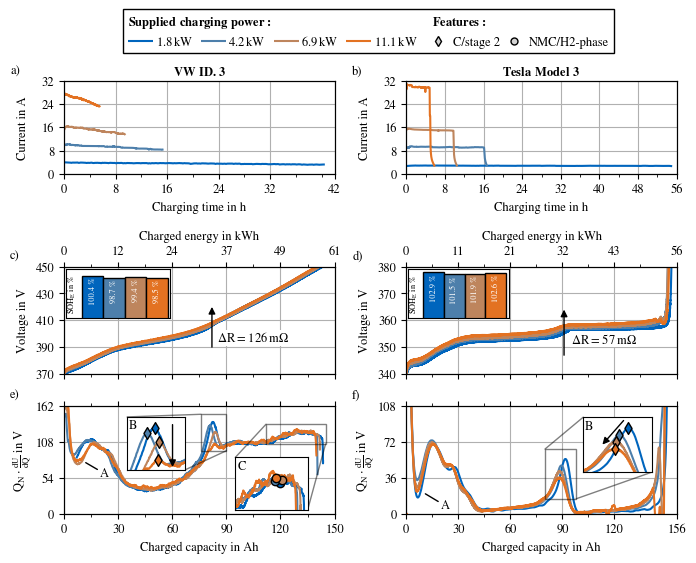

In [31]:
gridspec = dict(hspace=0.0, height_ratios=[1.3, 0.01, 1.5, 1.5])
#fig, axs = plt.subplots(nrows=4, ncols=2 )

nrows = 2
heigth = 4.2 #cm
fig, axes= plt.subplots(4,2,
                        figsize=(VisualizationConfig.textwidth_in_in.value,
                                3 * cm2inch(heigth)),gridspec_kw=gridspec,constrained_layout=True)
'''
plt.subplots_adjust(left=0.01,
                    bottom=0.01,
                    right=0.99,
                    top=0.99,
                    wspace=0.13,
                    hspace=0.6)
'''
axes[0][0] =  plot_current_vw(axes[0][0],
                                 lst_dfs =  [df_vw_288_C45, df_vw_288_C17, df_vw_288_C10, df_vw_288_C6])

axes[0][1] =  plot_current_tesla(axes[0][1],
                                 lst_dfs =  [df_tesla_C57, df_tesla_C17, df_tesla_C10, df_tesla_C5])

axes[1][0].set_visible(False)
axes[1][1].set_visible(False)

axes[2][0] = plot_pOCV_vw(axes[2][0],
                          lst_dfs = [df_vw_288_C45, df_vw_288_C17, df_vw_288_C10, df_vw_288_C6])


axes[2][1] = plot_pOCV_tesla(axes[2][1],
                            lst_dfs = [df_tesla_C57, df_tesla_C17, df_tesla_C10, df_tesla_C5])


axes[3][0] = plot_dva_vw(axes[3][0],
                          lst_cap = [cap_vw_288_C45, cap_vw_288_C17, cap_vw_288_C10, cap_vw_288_C6],
                          lst_dva = [dva_vw_288_C45, dva_vw_288_C17, dva_vw_288_C10, dva_vw_288_C6])

axes[3][1] = plot_dva_tesla(axes[3][1],
                            lst_cap = [cap_tesla_C57, cap_tesla_C17, cap_tesla_C10, cap_tesla_C5],
                            lst_dva = [dva_tesla_C57, dva_tesla_C17, dva_tesla_C10, dva_tesla_C5])


# legend
handles, labels =axes[0][0].get_legend_handles_labels()  
line1 = plt.hlines(0,0,1,label="$1.8\,kW$   ", color=colors[0])
line2 = plt.hlines(0,0,1,label="$4.2\,kW$   ", color=colors[1])
line3 = plt.hlines(0,0,1,label="$6.9\,kW$   ", color=colors[2])
line4 = plt.hlines(0,0,1,label="$11.1\,kW$   ", color=colors[3])


marker1 =mlines.Line2D([], [], color='lightgray', marker='d',linestyle="None",markeredgecolor="k",
                          markersize=5, label=r'C/stage 2')
marker2 =  mlines.Line2D([], [], color='lightgray', marker='o',linestyle="None",markeredgecolor="k",
                          markersize=5, label=r'NMC/H2-phase')
# add manual symbols to auto legend
handles.extend([line1, line2,line3,line4,marker1,marker2])
lgd=fig.legend(handles=handles,loc="center",fontsize=9,ncols=6,handletextpad=0.2,
            framealpha =1 , fancybox=False,labelspacing=-0.7,columnspacing=0.1,edgecolor="black",bbox_to_anchor=(0.53,1.06),title=r"$\bf{Supplied\ charging\ power:}$"+"\t\t\t\t\t\t"+r"    $\bf{Features:}$"+"\n",alignment='left')
for t in lgd.get_texts():
    t.set_verticalalignment('baseline')
#plt.tight_layout()

axes[0][0].text(-0.2, 1.1, 'a)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=axes[0][0].transAxes)
axes[0][1].text(-0.2, 1.1, r'b)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=axes[0][1].transAxes)
axes[2][0].text(-0.2, 1.1, r'c)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=axes[2][0].transAxes)
axes[2][1].text(-0.2, 1.1, r'd)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=axes[2][1].transAxes)
axes[3][0].text(-0.2, 1.1, r'e)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=axes[3][0].transAxes)
axes[3][1].text(-0.2, 1.1, r'f)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=axes[3][1].transAxes)

fig.savefig(os.path.join(GeneralConfig.path2figures.value,"02-FIG-C_Rate.pdf"),bbox_extra_artists=(lgd,), bbox_inches='tight') 
fig.savefig(os.path.join(GeneralConfig.path2figures.value,"02-FIG-C_Rate.png"),dpi=300, pad_inches = 0) 

# Resistance evaluation

In [32]:
def remove_outlier_IQR(signal,percentiles = [5,95]):
    Q1, Q3 = np.percentile(signal, percentiles)
    IQR = Q3 - Q1
    ul = Q3 + 1.5 * IQR
    ll = Q1 - 1.5 * IQR
    outliers = (signal > ul) | (signal < ll)
    return outliers

In [33]:
def plot_IR_vw(axes, lst_dfs = [],remove_outliers=True,percentiles = [5,95]):
    
    df1 = lst_dfs[0] 
    for ind,data in enumerate(lst_dfs[1:]):   
        df2 = lst_dfs[ind+1] 
        df_merge = pd.merge_asof(left = df1, right = df2, on='Q', suffixes=('_left', '_right'))
        df_merge = df_merge[(df_merge.SOC_left>=5)&(df_merge.SOC_left<=95)]
        # curr_filt1 = FilterMethods().rolling_mean_df(df_merge.I_left,window_size=FilterMethods().round_to_next_odd_number(len(df_merge.I_left)*1/100)).values[:,0]
        # curr_filt2 = FilterMethods().rolling_mean_df(df_merge.I_right,window_size=FilterMethods().round_to_next_odd_number(len(df_merge.I_right)*1/100)).values[:,0]
        curr_filt1 = df_merge.I_left
        curr_filt2 = df_merge.I_right
        resistance = (df_merge.U_left-df_merge.U_right)/(np.mean(curr_filt1)-np.mean(curr_filt2))*1000
    
        if remove_outliers:
            outliers = remove_outlier_IQR(resistance,percentiles = percentiles)
        else:
            outliers = np.zeros(len(resistance)).astype(bool)
        mR = np.mean(resistance[~outliers])*np.ones(len(df_merge.Q[~outliers]))
        axes.plot(df_merge.Q[~outliers], resistance[~outliers] ,color=orange_colors[ind+1])
        axes.plot(df_merge.Q[~outliers],mR,color="k",zorder=4,linewidth=2,label=f"{round(mR[0],2)} mOhm")
        
    axes.set_ylabel(r"$\Delta R$ in $m\Omega$",fontsize=9)
    #axes.set_xlabel(r"Charged capacity in Ah",fontsize=9) 
    axes.set_xlim([0,150])
    tick_positions = np.array([0,30,60,90,120,150])
    axes.set_xticks(tick_positions)
    #axes.set_ylim([0,600])
    #tick_positions = np.array([0,300,600])
    #axes.set_yticks(tick_positions)
    #axes.ticklabel_format(style='sci',scilimits=(2,2),axis='y')
    axes.grid(axis='both')
    # Minor X-axis divided into 10 parts between each X-axis major grid
    axes.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=False)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    axes.legend()
    #axes.plot([0,np.max(df_merge.Q[~outliers])],[mR,mR],color="k")
    #axes.annotate("MAE:"+str(round(mR))+"$\,m\Omega$",xy = (150-2,175),xytext=(150-2,175),fontsize=9,bbox=dict(boxstyle="square,pad=0",facecolor='white', edgecolor='none'),ha="right",va="center")
    
    twiny = axes.twiny()
    twiny.set_xlim(0,150)
    tick_positions = np.array([0,30,60,90,120,150])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([f"{x*df_merge.U_left.mean()/1000:.0f}" for x in tick_positions])
    twiny.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=False)
    return axes

In [34]:
def plot_IR_tesla(axes, lst_dfs = [],remove_outliers=True,percentiles = [5,95]):

    df1 = lst_dfs[0]
    for ind,data in enumerate(lst_dfs[1:]):   
        df2 = lst_dfs[ind+1]
        df_merge = pd.merge_asof(left = df1, right = df2, on='Q', suffixes=('_left', '_right'))
        df_merge = df_merge[(df_merge.SOC_left>=5)&(df_merge.SOC_left<=95)]
        # curr_filt1 = FilterMethods().rolling_mean_df(df_merge.I_left,window_size=FilterMethods().round_to_next_odd_number(len(df_merge.I_left)*1/100)).values[:,0]
        # curr_filt2 = FilterMethods().rolling_mean_df(df_merge.I_right,window_size=FilterMethods().round_to_next_odd_number(len(df_merge.I_right)*1/100)).values[:,0]
        curr_filt1 = df_merge.I_left
        curr_filt2 = df_merge.I_right
        resistance = (df_merge.U_left-df_merge.U_right)/(np.mean(curr_filt1)-np.mean(curr_filt2))*1000
    
        if remove_outliers:
            outliers = remove_outlier_IQR(resistance,percentiles = percentiles)
        else:
            outliers = np.zeros(len(resistance)).astype(bool)
        mR = np.mean(resistance[~outliers])*np.ones(len(df_merge.Q[~outliers]))
        axes.plot(df_merge.Q[~outliers], resistance[~outliers] ,color=blue_colors[ind+1])
        axes.plot(df_merge.Q[~outliers],mR,color="k",zorder=4,linewidth=2,label=f"{round(mR[0],2)} mOhm")

    axes.set_ylabel(r"$\Delta R$ in $m\Omega$",fontsize=9)
    #axes.set_xlabel(r"Charged capacity in Ah",fontsize=9) 
    axes.set_xlim([0,156])
    tick_positions = np.array([0,26,52,78,104,130,156])
    axes.set_xticks(tick_positions)
    #axes.set_ylim([0,600])
    #tick_positions = np.array([0,300,600])
    #axes.set_yticks(tick_positions)
    #axes.ticklabel_format(style='sci',scilimits=(1,1),axis='y')
    axes.grid(axis='both')
    axes.xaxis.set_minor_locator(FixedLocator([13,39,65,91,117,143]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=False)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    axes.legend()

    #axes.plot([0,np.max(df_merge.Q[~outliers])],[mR,mR],color="k")
    #axes.annotate("MAE:"+str(round(mR))+"$\,m\Omega$",xy = (156-2,3500),xytext=(156-2,3500),fontsize=9,bbox=dict(boxstyle="square,pad=0",facecolor='white', edgecolor='none'),ha="right",va="center")
    #axes.yaxis.set_label_coords(-0.13,0.5)

    #axes.annotate("$\Delta R= 50\,k\Omega$",xy = (105,351.5),xytext=(105,351.5),fontsize=9,bbox=dict(boxstyle="square,pad=0",facecolor='white', edgecolor='none'))
    #axes.annotate("",xy = (104,350),xytext=(104,365),arrowprops=dict(arrowstyle='<|-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=10))
    
    twiny = axes.twiny()
    twiny.set_xlim(0,156)
    tick_positions = np.array([0,26,52,78,104,130,156])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([13,39,65,91,117,143]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([f"{x*df_merge.U_left.mean()/1000:.0f}" for x in tick_positions])
    twiny.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=False)
    return axes

In [35]:
def plot_T_vw(axes, lst_dfs = []):
    
    for ind,data in enumerate(lst_dfs):
        try:
            axes.plot(lst_dfs[ind].Q,lst_dfs[ind].pack_temp_0,color=orange_colors[ind],linewidth=1.5)
        except:
            continue
    axes.set_ylabel(r"Temperature in $\circ C$",fontsize=9)
    axes.set_xlabel(r"Charged capacity in Ah",fontsize=9) 
    axes.set_xlim([0,150])
    tick_positions = np.array([0,30,60,90,120,150])
    axes.set_xticks(tick_positions)
    axes.set_ylim([0,40])
    #tick_positions = np.array([0,300,600])
    #axes.set_yticks(tick_positions)
    #axes.ticklabel_format(style='sci',scilimits=(2,2),axis='y')
    axes.grid(axis='both')
    # Minor X-axis divided into 10 parts between each X-axis major grid
    axes.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    
    twiny = axes.twiny()
    twiny.set_xlim(0,150)
    tick_positions = np.array([0,30,60,90,120,150])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([f"{x*lst_dfs[0].U.mean()/1000:.0f}" for x in tick_positions])
    twiny.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=False)
    return axes

In [36]:
def plot_T_tesla(axes, lst_dfs = []):
    
    for ind,data in enumerate(lst_dfs):
        axes.plot(lst_dfs[ind].Q,lst_dfs[ind].pack_temp_max,color=blue_colors[ind],linewidth=1.5)
        
    axes.set_ylabel(r"Temperature in $\circ C$",fontsize=9)
    axes.set_xlabel(r"Charged capacity in Ah",fontsize=9) 
    axes.set_xlim([0,150])
    tick_positions = np.array([0,30,60,90,120,150])
    axes.set_xticks(tick_positions)
    axes.set_ylim([0,40])
    #tick_positions = np.array([0,300,600])
    #axes.set_yticks(tick_positions)
    #axes.ticklabel_format(style='sci',scilimits=(2,2),axis='y')
    axes.grid(axis='both')
    # Minor X-axis divided into 10 parts between each X-axis major grid
    axes.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    
    twiny = axes.twiny()
    twiny.set_xlim(0,150)
    tick_positions = np.array([0,30,60,90,120,150])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([f"{x*lst_dfs[0].U.mean()/1000:.0f}" for x in tick_positions])
    twiny.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=False)
    return axes

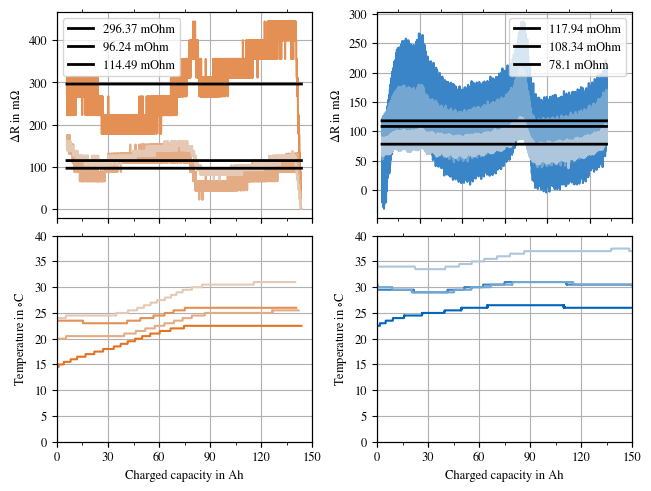

In [37]:
fig, axes= plt.subplots(2,2,constrained_layout=True)
axes[0,0] = plot_IR_vw(axes[0,0], lst_dfs =  [df_vw_288_C45,df_vw_288_C17,  df_vw_288_C10, df_vw_288_C6], remove_outliers=False,percentiles = [20,80])
axes[0,1] = plot_IR_tesla(axes[0,1], lst_dfs = [df_tesla_C57, df_tesla_C17, df_tesla_C10, df_tesla_C5],remove_outliers=False,percentiles = [20,80])

axes[1,0] = plot_T_vw(axes[1,0], lst_dfs =  [df_vw_288_C45,df_vw_288_C17,  df_vw_288_C10, df_vw_288_C6])
axes[1,1] = plot_T_tesla(axes[1,1], lst_dfs = [df_tesla_C57, df_tesla_C17, df_tesla_C10, df_tesla_C5])